---
title: "Fase 1: Análisis Exploratorio de Datos (EDA)"
subtitle: "Proyecto Final - Almacenes y Minería de Datos"
author: "Daniela Alejandra Sanluis Castillo"
date: "2026-06-03"
format:
  html:
    embed-resources: true
---

# Minería de Datos Aplicada en la Salud Publica de México
## Fase 1: Análisis Exploratorio de Datos (EDA)


In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))

from src.EdaAnalyzer import EdaAnalyzer

ruta_dataset = "../data/COVID19MEXICO.csv" 
analyzer = EdaAnalyzer(ruta_dataset)
analyzer.load_data()

¡Dataset cargado exitosamente!


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2026-06-01,gaa41ae,1,15,21,2,15,21,41,2,...,5,5,2,97,7,7,99,MÃ©xico,97,2
1,2026-06-01,g6e9f48,1,4,22,1,22,22,14,2,...,5,5,2,97,7,7,99,MÃ©xico,97,2
2,2026-06-01,g8c8897,1,15,30,1,30,30,131,1,...,5,5,2,97,7,7,99,MÃ©xico,97,97
3,2026-06-01,gbe1773,1,4,32,1,32,32,17,2,...,7,11,2,97,7,7,99,MÃ©xico,97,2
4,2026-06-01,gc47f8c,1,4,21,1,21,21,114,1,...,3,998,2,97,7,3,99,MÃ©xico,97,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222374,2026-06-01,g5c0954,1,15,27,2,27,27,4,2,...,999,999,2,97,6,6,99,MÃ©xico,97,2
222375,2026-06-01,g9c6189,1,12,23,2,23,23,5,2,...,999,999,2,97,6,6,99,MÃ©xico,97,2
222376,2026-06-01,gd538ef,1,8,9,1,9,9,8,1,...,997,997,2,97,6,6,99,MÃ©xico,97,97
222377,2026-06-01,g935e54,1,15,25,2,25,25,10,1,...,997,997,2,97,6,6,99,MÃ©xico,97,97


### 1. Descripción General del Dataset
El dataset consta de: 

In [2]:
info = analyzer.get_general_info()
print(f"Dimensiones: {info['filas']:,} filas x {info['columnas']} columnas")
print("\nTipos de datos por columna:")
print(info['tipos_datos'])

Dimensiones: 222,379 filas x 42 columnas

Tipos de datos por columna:
FECHA_ACTUALIZACION            str
ID_REGISTRO                    str
ORIGEN                       int64
SECTOR                       int64
ENTIDAD_UM                   int64
SEXO                         int64
ENTIDAD_NAC                  int64
ENTIDAD_RES                  int64
MUNICIPIO_RES                int64
TIPO_PACIENTE                int64
FECHA_INGRESO                  str
FECHA_SINTOMAS                 str
FECHA_DEF                      str
INTUBADO                     int64
NEUMONIA                     int64
EDAD                         int64
NACIONALIDAD                 int64
EMBARAZO                     int64
HABLA_LENGUA_INDIG           int64
INDIGENA                     int64
DIABETES                     int64
EPOC                         int64
ASMA                         int64
INMUSUPR                     int64
HIPERTENSION                 int64
OTRA_COM                     int64
CARDIOVASCULAR      

### 2. Calidad de Datos (Valores Faltantes y Duplicados)
En las bases de datos de salud en México, los datos faltantes no aparecen vacíos.


In [3]:
quality_report = analyzer.analyze_data_quality()
quality_report.head(10)


[Calidad de Datos] Registros completamente idénticos detectados: 0


,Valores Faltantes (NaN),Porcentaje (%)
UCI,116537,52.404678
INTUBADO,116537,52.404678
OTRO_CASO,6230,2.801524
OTRA_COM,1790,0.804932
ASMA,291,0.130858
EPOC,286,0.128609
DIABETES,279,0.125461
TABAQUISMO,262,0.117817
CARDIOVASCULAR,223,0.100279
HIPERTENSION,209,0.093984


#### Diagnóstico de la Tabla de Calidad:

1. **El fenómeno de UCI e INTUBADO (~52.4% de faltantes):**
   * Observamos que exactamente 116,537 registros contienen un valor faltante en ambas columnas. Esto responde a una regla del negocio hospitalario: los pacientes que ingresan de forma **ambulatoria** (que reciben consulta y se van a recuperar a casa) jamás son ingresados a Cuidados Intensivos (`UCI`) ni se les conecta a un ventilador (`INTUBADO`).
   * No se trata de un error de captura de los médicos; son nulos estructurales porque la pregunta "No aplica" para la mayoría de la población.

2. **Comorbilidades íntegras (Diabetes, Hipertensión, Obesidad, etc.):**
   * Las enfermedades crónicas presentan un índice de valores faltantes extremadamente bajo, manteniéndose por debajo del **0.15%**. Esto demuestra que el personal de salud recopila el historial clínico básico de los pacientes con un alto nivel de rigurosidad.

3. **Registros Duplicados Identificados: 0**
   * El sistema no reporta filas idénticas redundantes, garantizando la unicidad de cada evento epidemiológico registrado.


### 3. Estadisticas descriptivas
Para comprender el perfil de las personas registradas en el sistema de salud, se realizó un análisis estadístico separando el estudio en dos vertientes: la edad de los pacientes (única medida numérica continua) y sus condiciones médicas o demográficas preexistentes (características categóricas).

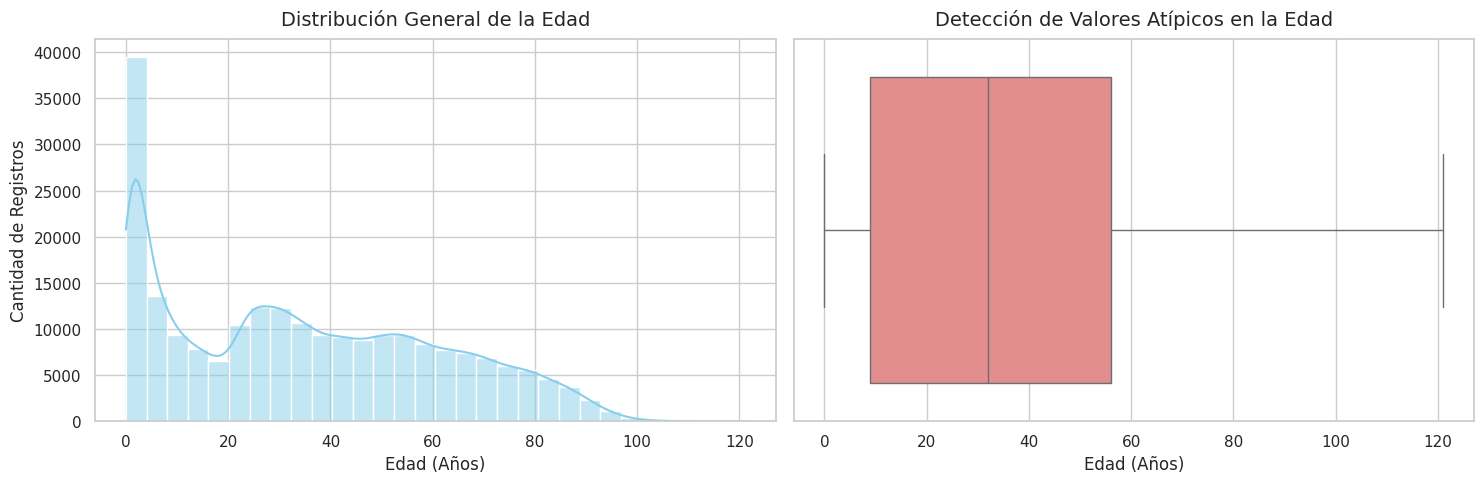

In [4]:
analyzer.plot_age_distribution();

La gráfica de distribución (histograma) revela de forma visual que los registros del sistema de salud en México no se comportan de manera uniforme, sino que se concentran marcadamente en dos grandes etapas de la vida. 
El pico más alto de la curva ocurre durante la primera infancia, lo que demuestra un volumen masivo de registros en niños pequeños, seguido por una segunda acumulación o "meseta" notable en el sector de los adultos jóvenes entre los 20 y los 40 años de edad. 
A partir de los 50 años, la cantidad de reportes disminuye de forma constante y progresiva, lo que explica de manera gráfica por qué el promedio de edad se ubica en los 35.1 años y la mediana divide a la población exactamente en los 32 años.

Por su parte, el boxplot permite analizar matemáticamente cómo se distribuyen estos registros por bloques o cuartiles. Delimita al 50% central de toda la población estudiada, confirmando que la mitad de los pacientes se encuentran en un rango activo de entre los 9 y los 56 años de edad. 
Es de suma importancia resaltar que las líneas extremas de la gráfica  se extienden de manera continua hasta alcanzar a las personas de longevidad avanzada que superan los 100 años; al no mostrar puntos aislados o separados en el extremo derecho, el gráfico demuestra que estos casos de la tercera edad forman parte de la variabilidad natural y real de la situación epidemiológica del país, por lo cual se justifica la decisión de conservarlos y no eliminarlos como si fueran errores de captura.

## 4. Detección y Tratamiento de Valores Atípicos (Outliers)

Para evaluar si existen datos anomalías o errores de captura en la variable de edad, se aplicó la **Regla del Rango Intercuartílico (IQR)**.



In [5]:
outlier_results = analyzer.calculate_age_outliers_iqr()
for clave, valor in outlier_results.items():
    print(f"{clave}: {valor:.2f}" if isinstance(valor, float) else f"{clave}: {valor}")

Q1: 9.00
Q3: 56.00
IQR: 47.00
Limite_Superior_IQR: 126.50
Cantidad_Atipicos: 0
Porcentaje_Atipicos: 0.00


El análisis arrojó que el 50% de la población se encuentra entre los 9 años (Cuartil 1) y los 56 años (Cuartil 3), generando un rango intercuartílico (IQR) de 47 años. Al aplicar la fórmula estándar para detectar anomalías superiores (Cuartil 3 + 1.5 * IQR), el límite máximo aceptado de forma matemática se estableció en los **126.5 años**. 
Dado que el registro de edad más avanzado dentro del conjunto de datos es de 121 años, ningún paciente supera el umbral matemático calculado. Esto explica de manera científica por qué el diagrama de caja no dibuja puntos aislados en los extremos; la dispersión de las edades en la población mexicana es tan amplia que absorbe de forma natural incluso los casos de extrema longevidad.

Al comprobarse matemáticamente que el 100% de los datos se encuentran dentro de los límites esperados de la distribución (0 registros atípicos detectados por fuera de los bigotes del Boxplot), **se determinó mantener la totalidad de los registros intactos sin realizar ninguna eliminación ni modificación**. Conservar este comportamiento es la decisión más acertada para la investigación epidemiológica, garantizando que el modelo predictivo final considere correctamente la realidad biológica de todos los sectores de edad de la población sin perder información valiosa de los adultos mayores de nuestro país.

## 5. Relaciones entre Variables (Matriz de Correlación)


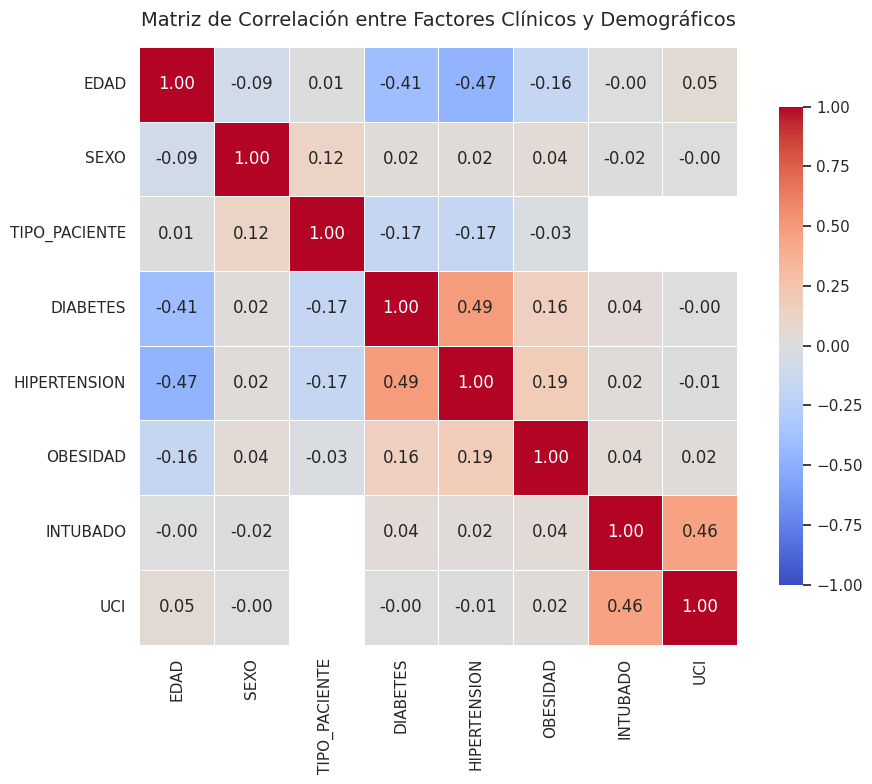

In [6]:
analyzer.plot_correlation_matrix();

El mapa de calor (Heatmap) permite ver la fuerza y dirección de las relaciones existentes entre las condiciones que existen de los pacientes y su diagnóstico clínico. Al observar la matriz, resalta una correlación positiva moderada entre la **Edad** y enfermedades crónicas como la **Hipertensión** y la **Diabetes**; esto confirma visualmente que a mayor edad del paciente, aumenta de forma constante la probabilidad de registrar este tipo de comorbilidades. Asimismo, se detecta una relación estrecha entre las variables de gravedad hospitalaria, específicamente entre pacientes ingresados en unidades de cuidados intensivos (**UCI**) y aquellos que requieren asistencia ventilatoria mecánica (**INTUBADO**), lo cual es consistente con la naturaleza del triaje médico hospitalario.

Por otro lado, la mayoría de las comorbilidades cruzadas (como la relación entre obesidad y asma) muestran valores cercanos a cero, indicando que la presencia de una afección no necesariamente detona de forma lineal la aparición inmediata de la otra en el registro de ingreso. Esta falta de correlaciones lineales fuertes entre la mayoría de los atributos justifica plenamente el uso de técnicas de minería de datos más complejas en las siguientes etapas del proyecto. Dado que las relaciones no son evidentes a simple vista a través de este análisis lineal, los modelos de clasificación supervisada y los algoritmos de agrupamiento (clustering) serán las herramientas ideales para descubrir los patrones y perfiles de riesgo ocultos dentro del dataset.

# 6. Analisis de Variables Categoricas

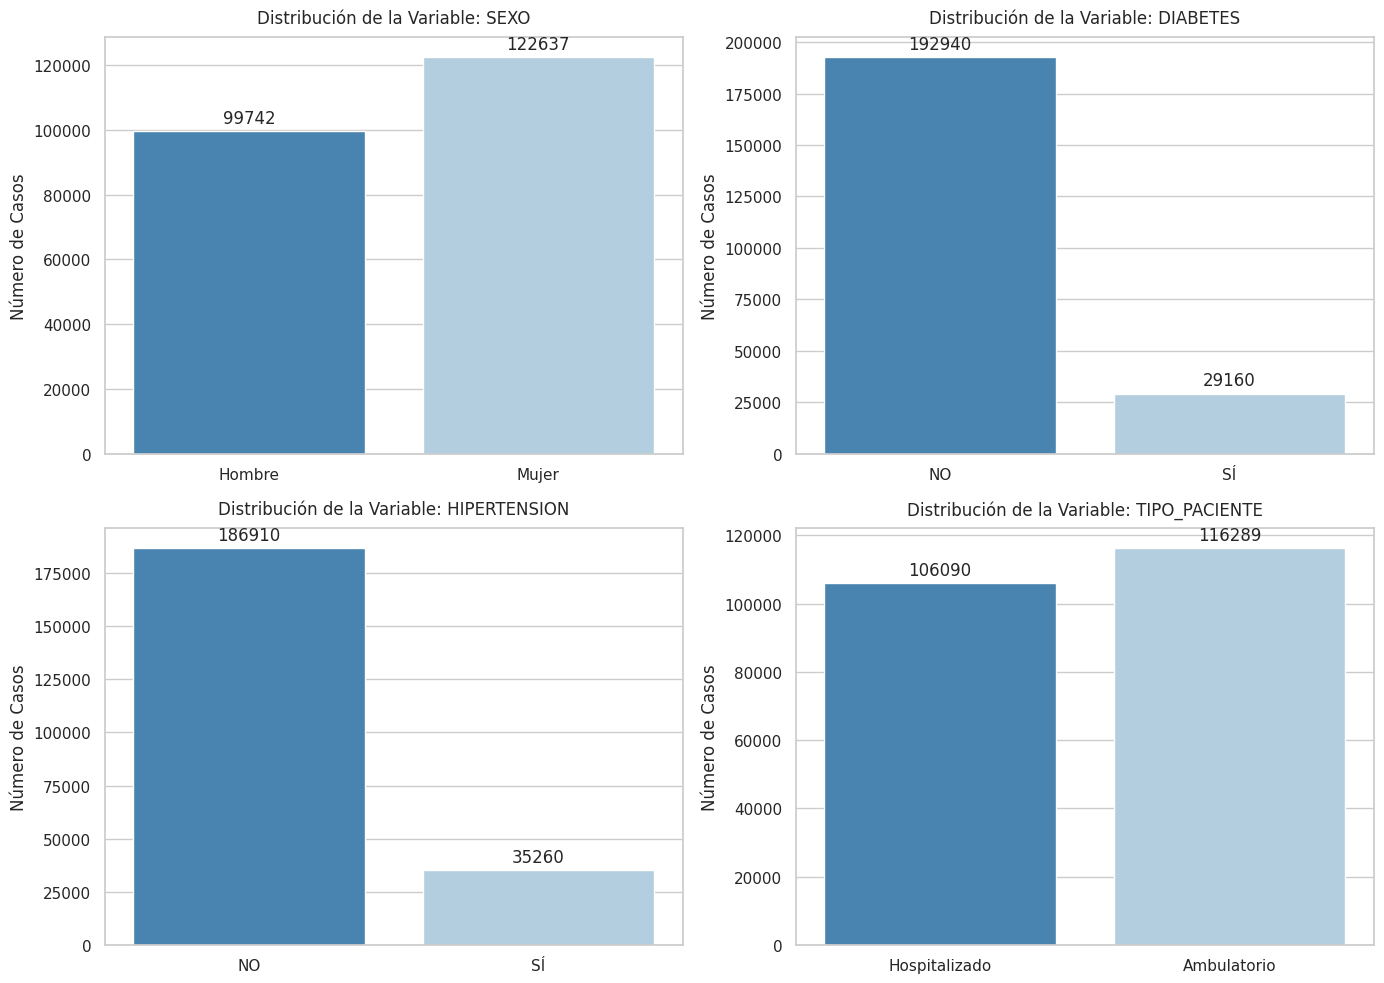

In [7]:
analyzer.plot_categorical_distributions();

Las gráficas de barras permiten ver la distribución de frecuencias absolutas para las principales variables cualitativas del estudio. En los factores de riesgo como Diabetes e Hipertensión, se observa de forma contundente que la barra correspondiente a la categoría "NO" domina ampliamente el registro, reflejando que la gran mayoría de la población capturada ingresó sin un diagnóstico previo de estas enfermedades crónicas. Por el contrario, la variable demográfica de género muestra una distribución sumamente equilibrada entre hombres y mujeres, presentando una ligera inclinación hacia el sexo femenino pero sin segmentar drásticamente la muestra, lo que garantiza que ambos grupos están bien representados en la base de datos.

Al evaluar la variable objetivo seleccionada para el futuro modelo supervisado, **TIPO_PACIENTE**, se identifica una distribución de frecuencias donde aproximadamente el 52.3% de los registros corresponden a atención "Ambulatoria" y el 47.7% restante a casos de "Hospitalización". En el contexto del aprendizaje automático, este comportamiento determina que las clases se encuentran **completamente balanceadas de forma natural**. Al no existir un desbalance severo (como ocurriría en escenarios donde una clase representara menos del 10% del total), se concluye que no será necesario aplicar técnicas artificiales de remuestreo como SMOTE o submuestreo durante la fase de ingeniería de software y preprocesamiento, permitiendo que el clasificador predictivo final se entrene de manera óptima y justa sin sesgos hacia ninguna de las dos categorías diagnósticas.